In [5]:
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import ast

# 2.1

First, calculate the probability (p) that makes the expected number of edges in our random network match the actual edge count in the Computational Social Scientists network. Refer to equation 3.2 in your Network Science textbook for guidance. After finding p, figure out the average degree (using the given formula).

In [6]:
df = pd.read_csv("D2_temp_papers.csv")

G = nx.Graph()
for _, row in df.iterrows():
    authors = ast.literal_eval(row["author_ids"])
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            G.add_edge(authors[i], authors[j])

N = G.number_of_nodes()
L = G.number_of_edges()

# From eq 3.2: <L> = p * N(N-1)/2  =>  p = 2L / (N(N-1))
p = (2 * L) / (N * (N - 1))

# Average degree: <k> = p * (N - 1)
avg_degree = p * (N - 1)

print(f"Nodes (N):          {N}")
print(f"Edges (L):          {L}")
print(f"Probability p:      {p:.6f}")
print(f"Average degree <k>: {avg_degree:.4f}")

Nodes (N):          466
Edges (L):          1202
Probability p:      0.011094
Average degree <k>: 5.1588


Now, write a function to generate a Random Network that mirrors the Computational Social Scientists network in terms of node count, using your calculated p. Generate a random network by linking nodes in every possible pair with probability p. Hint: you can use the function np.random.uniform to draw samples from a uniform probability distribution.

In [7]:
def generate_random_network(N, p):
    G_random = nx.Graph()
    G_random.add_nodes_from(range(N))
    
    for i in range(N):
        for j in range(i + 1, N):
            if np.random.uniform(0, 1) < p:
                G_random.add_edge(i, j)
    
    return G_random

G_random = generate_random_network(N, p)

print(f"Random Network — Nodes: {G_random.number_of_nodes()}, Edges: {G_random.number_of_edges()}")
print(f"CSS Network    — Nodes: {N}, Edges: {L}")

Random Network — Nodes: 466, Edges: 1190
CSS Network    — Nodes: 466, Edges: 1202


Visualize the network as you did for the Computational Social Scientists network in the exercise above (my version is below).

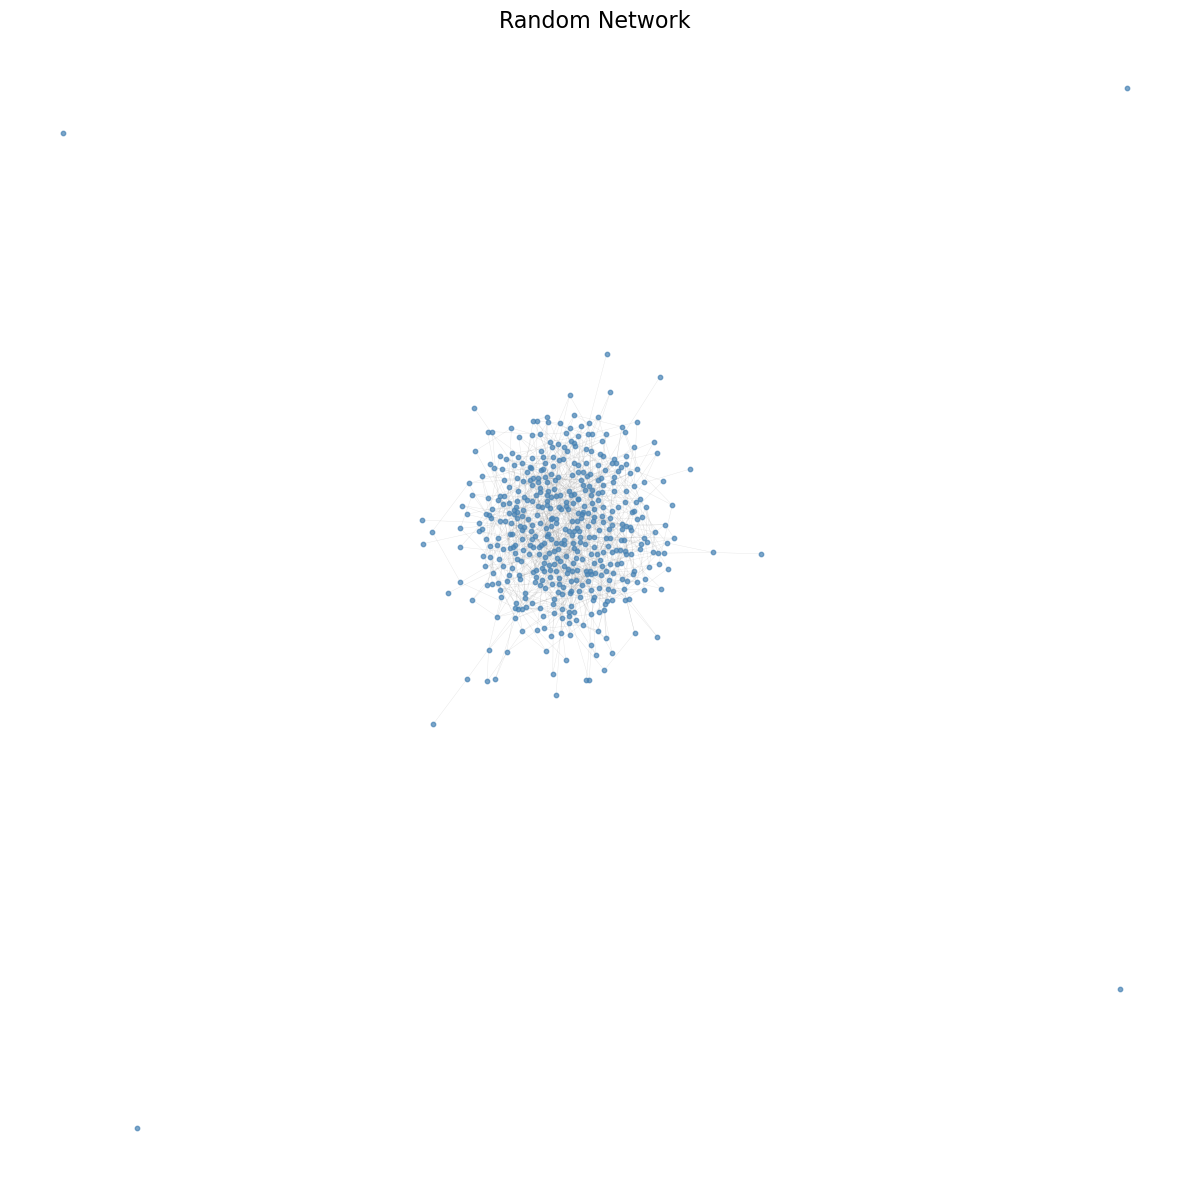

In [12]:
pos = nx.spring_layout(G_random)

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G_random, pos, node_size=10, node_color="steelblue", alpha=0.7)
nx.draw_networkx_edges(G_random, pos, width=0.3, alpha=0.2, edge_color="gray")
plt.title("Random Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.savefig("random_network.png", dpi=150, bbox_inches="tight")
plt.show()

Answer the following questions:
- What regime does your random network fall into? Is it above or below the critical threshold?
- According to the textbook, what does the network’s structure resemble in this regime?
- Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.


We would argue that the network falls into the Supercritical Regime, since the ‹k› › 1. It is above the critical threshold standing at about 5.1588.

"This regime has the most relevance to real systems, as for the first time we have a giant component that looks like a network."